In [1]:
import warnings
warnings.filterwarnings('error')

# Incorporação dos dados

Primeiros os dados são baixados via KaggleHub. 

O dataset utiliza está presente em: [https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification](https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification).

Para realizar o download é necessário ter uma conta no Kaggle e no caso do download via API(KaggleHub) é necessário ter uma API KEY. Para mais informações veja: [https://www.kaggle.com/account/login](https://www.kaggle.com/account/login) e [https://www.kaggle.com/docs/api](https://www.kaggle.com/docs/api), respectivamente. Para facilitar o uso da API, foi disponibilizado um arquivo neste projeto com o nome `key-setup-example.sh`. Use este arquivo como base adicionando sua API KEY nele. Posteriormente, o renomeie para `key-setup.sh` e execute `make analysis`.

Este script leva em consideração um ambiente linux com as seguintes dependencias instaladas:
- Make
- UV

In [2]:
import kagglehub

print("Fazendo Download do dataset...")
dataset_path = kagglehub.dataset_download("shivamb/machine-predictive-maintenance-classification")
print("Path to dataset files:", dataset_path)

Fazendo Download do dataset...
Path to dataset files: /home/alexandre/.cache/kagglehub/datasets/shivamb/machine-predictive-maintenance-classification/versions/1


In [3]:
import os

print("Arquivos presentes no diretório: ", dataset_path)
files = os.listdir(dataset_path)
print("Arquivos: ", files)

Arquivos presentes no diretório:  /home/alexandre/.cache/kagglehub/datasets/shivamb/machine-predictive-maintenance-classification/versions/1
Arquivos:  ['predictive_maintenance.csv']


In [4]:
PATH_CSV = os.path.join(dataset_path, files[0])

# Análise Exploratória

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(PATH_CSV)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


A Descrição do dataset é a seguinte:

```
Machine Predictive Maintenance Classification Dataset
Since real predictive maintenance datasets are generally difficult to obtain and in particular difficult to publish, we present and provide a synthetic dataset that reflects real predictive maintenance encountered in the industry to the best of our knowledge.

The dataset consists of 10 000 data points stored as rows with 14 features in columns

UID: unique identifier ranging from 1 to 10000
productID: consisting of a letter L, M, or H for low (50% of all products), medium (30%), and high (20%) as product quality variants and a variant-specific serial number
air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
rotational speed [rpm]: calculated from powepower of 2860 W, overlaid with a normally distributed noise
torque [Nm]: torque values are normally distributed around 40 Nm with an Ïƒ = 10 Nm and no negative values.
tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process. and a 'machine failure' label that indicates, whether the machine has failed in this particular data point for any of the following failure modes are true.

Important : There are two Targets - Do not make the mistake of using one of them as feature, as it will lead to leakage.

- Target : Failure or Not
- Failure Type : Type of Failure
```

Como no nosso caso queremos fazer a classificação com mais de dois valores, usamos o targe como a coluna `Failure Type`.

In [7]:
TARGET = "Failure Type"

In [8]:
print("identificação dos tipos das colunas")
display(df.info())

identificação dos tipos das colunas
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


None

In [9]:
print("Descrição da distribuição dos dados")
display(df.describe())

Descrição da distribuição dos dados


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [10]:
print("Quantidade de valores NaN")
display(df.isna().sum())

Quantidade de valores NaN


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [11]:
print("Quantidade de valores NULL")
display(df.isnull().sum())

Quantidade de valores NULL


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Como visto, não há dados faltantes. Isso era esperado por ser um dataset com usabilidade `10.0` no Kaggle. Sendo assim, podemos buscar entender melhor como os dados estão distribuidos em busca de fatores como `outliers`, possiveis padronizações, e limpezas que podem ser feitas.

A primeira coisa que gostaria de saber é a quantidade de dados por classe. Antes de tudo, vou verificar a quantidade de classes distintas por `Tipo de falha`

In [12]:
print("Quantidade de classes por `Tipo de Falha`")
classes = df[TARGET].unique().tolist()
print("Classes: ", classes)
print("Total classes: ", len(classes))

Quantidade de classes por `Tipo de Falha`
Classes:  ['No Failure', 'Power Failure', 'Tool Wear Failure', 'Overstrain Failure', 'Random Failures', 'Heat Dissipation Failure']
Total classes:  6


Agora que sabe-se a quantidade, seria interessante saber quão bem distribuidos estas estão

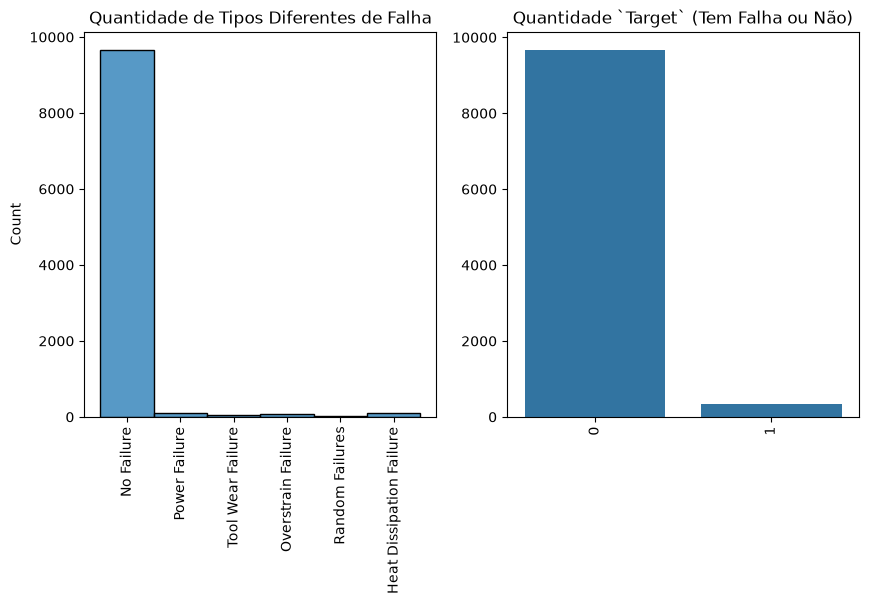

In [13]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

# plot Failure Type
sns.histplot(data=df, x=TARGET, ax=ax[0])
ax[0].tick_params(axis='x',rotation=90)
ax[0].set_xlabel("")
ax[0].set_title("Quantidade de Tipos Diferentes de Falha")

# plot Target
sns.countplot(data=df, x='Target',ax=ax[1])
ax[1].tick_params(axis='x',rotation=90)
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_title("Quantidade `Target` (Tem Falha ou Não)")

plt.show()

É possível ver que há uma enorme discrepância entre casos sem falha e com falha!

Vamos ver como estão distribuidas as instâncias dentre os dados representativos à máquinas com falhas

In [14]:
failed = df.loc[df.Target == 1]
no_fail = df.loc[df.Target == 0]

print(f"Quantidade total de linhas com Falha: {len(failed)}/{len(df)}")
print(f"Quantidade total de linhas sem Falha: {len(no_fail)}/{len(df)}")

display(failed.head())

Quantidade total de linhas com Falha: 339/10000
Quantidade total de linhas sem Falha: 9661/10000


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,Power Failure
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,Power Failure
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,Tool Wear Failure
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,Overstrain Failure
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,Overstrain Failure


Sabe-se que `Type` descreve variantes com relação à controle de qualidade: 

```
L, M, or H for low (50% of all products), medium (30%), and high (20%) as product quality
```

Assim, vamos observar a distribuição destes tipos entre produtos com falha e sem

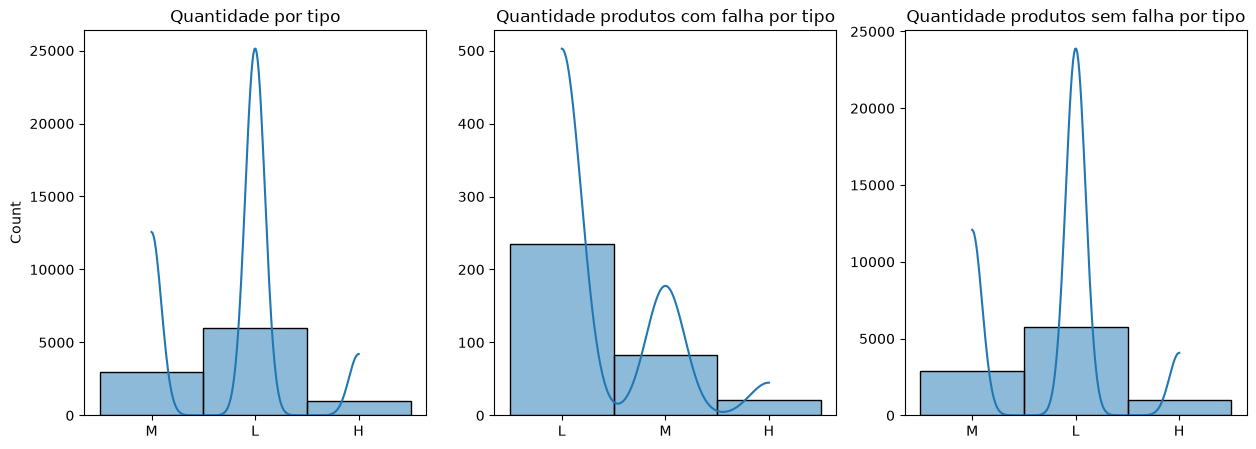

In [15]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

# quantidade por tipos
sns.histplot(data=df, x="Type", ax=ax[0], kde=True)
ax[0].set_title("Quantidade por tipo")

# distribuição quantidade de tipos com falha
sns.histplot(data=failed, x="Type", ax=ax[1], kde=True)
ax[1].set_title("Quantidade produtos com falha por tipo")

# distribuição quantidade de tipos sem falha
sns.histplot(data=no_fail, x="Type", ax=ax[2], kde=True)
ax[2].set_title("Quantidade produtos sem falha por tipo")

for i in range(3):
    ax[i].set_xlabel("")
    if i > 0:
        ax[i].set_ylabel("")

plt.show()

Agora dentre o split, quantos são de cada tipo de falha

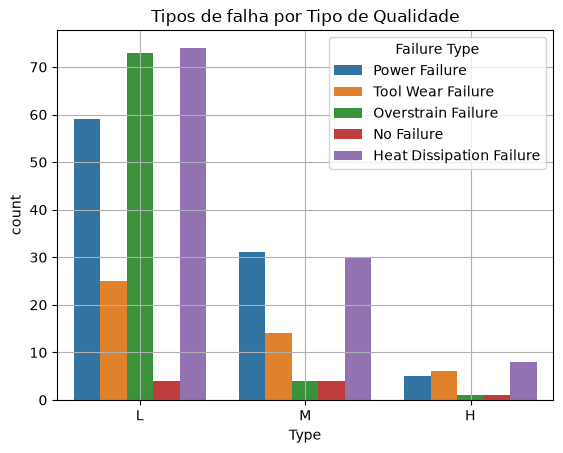

In [16]:
sns.countplot(data=failed, x="Type", hue=TARGET)
plt.grid()
plt.title("Tipos de falha por Tipo de Qualidade")
plt.show()

Interssante que mesmo sendo a parte só com falhas, o valor `No Failure` Apareceu, isso pode ser um mismatch entre as colunas target

In [17]:
print("Verificação de mismatches Failure e No Failure")

no_failed_on_failed = failed.loc[failed[TARGET] == "No Failure"]
failed_on_no_failed = no_fail.loc[no_fail[TARGET] != "No Failure"]

print("Sem Falhas no split com falhas: ", len(no_failed_on_failed))
print("Com Falhas no split sem falhas: ", len(failed_on_no_failed))

Verificação de mismatches Failure e No Failure
Sem Falhas no split com falhas:  9
Com Falhas no split sem falhas:  18


Como não podemos saber a natureza desses dados, vamos removê-los do dataset

In [18]:
clean_df = df.drop(no_failed_on_failed.index).drop(failed_on_no_failed.index)
print(f"Novo total de linhas {len(df)} -> {len(clean_df)}")

failed_clean = clean_df.loc[clean_df.Target == 1]
no_fail_clean = clean_df.loc[clean_df.Target == 0]

print(f"Quantidade total de linhas com Falha: {len(failed_clean)}/{len(clean_df)}")
print(f"Quantidade total de linhas sem Falha: {len(no_fail_clean)}/{len(clean_df)}")

Novo total de linhas 10000 -> 9973
Quantidade total de linhas com Falha: 330/9973
Quantidade total de linhas sem Falha: 9643/9973


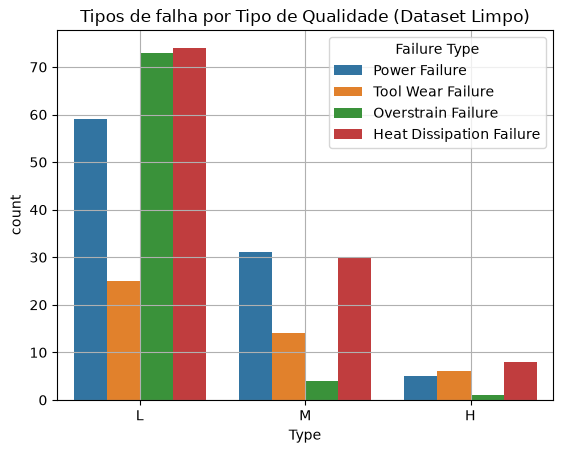

In [19]:
sns.countplot(data=failed_clean, x="Type", hue=TARGET)
plt.grid()
plt.title("Tipos de falha por Tipo de Qualidade (Dataset Limpo)")
plt.show()

Para termos uma ideia melhor de cada problema, vamos montar uma lista com o que cada uma é:

| Failure Type | Description | reference |
|--------------|-------------|-----------|
| Power Failure | When utility power is lost — whether from a storm, grid fault, or equipment failure — voltage abruptly drops. That’s the outage itself. However, the risk to equipment does not just come from the outage, but from what follows when power returns.Restoration causes transient overvoltage. When circuits re-energize, transient overvoltage is created, increasing voltage and unleashing “a high frequency ringing on top of the 60-Hz power frequency.”² This increase in voltage doesn’t just spike once and disappear; it often oscillates rapidly, swinging above and below the normal voltage level in a “ringing” or ripple pattern before settling down | https://maxivolt.com/home/why-power-outages-cause-equipment-failure-and-how-to-prevent-it/ |
| Tool Wear Failure | the gradual breakdown of machine tools as a result of cutting operation, eventually leading to tool failure ... Metal-to-metal contact and high stress and pressure. It is also subject to very high temperatures. | https://www.machinemetrics.com/blog/tool-wear |
| Overstrain Failure |  if the product of tool wear and torque exceeds 11,000 minimum Nm for the L product variant (12,000 for M, 13,000 for H), the process fails due to overstrain. | https://learn.microsoft.com/en-us/fabric/data-science/predictive-maintenance |
| Heat Dissipation Failure | Excessive heat buildup in electrical panels, mechanical systems, and industrial equipment can lead to component degradation, insulation failure, and even catastrophic breakdowns. | https://volterrat.com/overheating-thermal-failures/ |


Algumas ideias:
- Ver se todos com `Overstrain Failure` tiveram aquele excesso de Torque minimo
- Analisar se `Heat Dissipation Failure` tem relação com `Tool Wear Failure`
- Analisar `Random Failures`, que não apareceram aqui (verificar se está dentro do dataset de no failures)

## Verificando o Random Failures

In [22]:
print("Dados Sujos  - tipos de falhas (df sem falhas): ", no_fail[TARGET].unique().tolist())
print("Dados limpos - tipos de falhas (df sem falhas): ", no_fail_clean[TARGET].unique().tolist())

Dados Sujos  - tipos de falhas (df sem falhas):  ['No Failure', 'Random Failures']
Dados limpos - tipos de falhas (df sem falhas):  ['No Failure']


Pelo visto, `Random Failures` foi tido como nenhuma falha evidente. Talves o ideal, ao invés de remover estes dados, é remodela-los para `Target=1`

## Verificando `Overstrain Failure`

In [24]:
print("Colunas: ", df.columns.tolist())

Colunas:  ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']


In [28]:
overstrain_columns = ['Torque [Nm]', 'Tool wear [min]']
print("Descrição dos valores das colunas: ", overstrain_columns) 
display(df[overstrain_columns].describe())

Descrição dos valores das colunas:  ['Torque [Nm]', 'Tool wear [min]']


,Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000
mean,39.986910,107.951000
std,9.968934,63.654147
min,3.800000,0.000000
25%,33.200000,53.000000
50%,40.100000,108.000000
75%,46.800000,162.000000
max,76.600000,253.000000


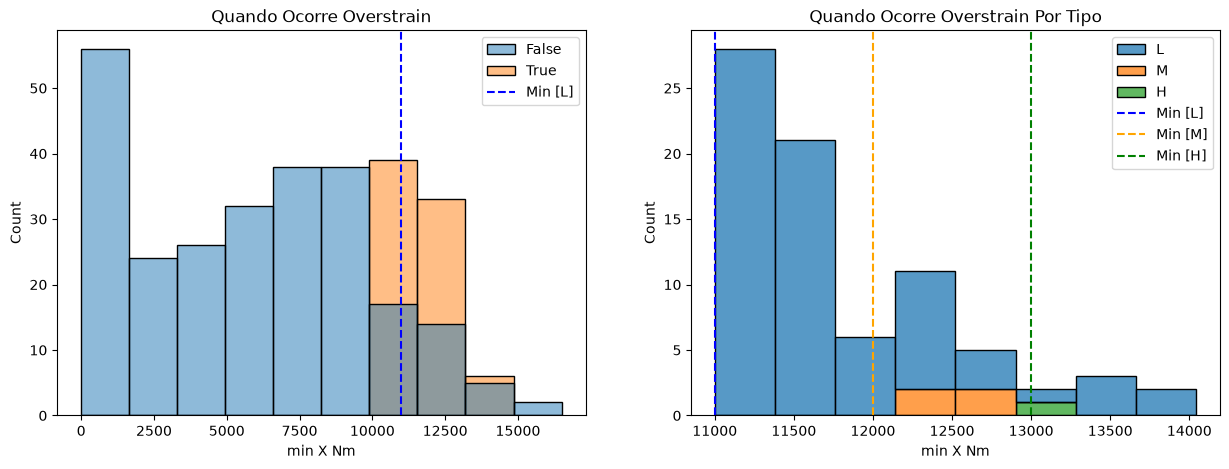

In [61]:
overstrain_df = failed_clean.copy()

overstrain_df["overstrain"] = False
overstrain_df.loc[overstrain_df[TARGET] == "Overstrain Failure", "overstrain"] = True

overstrain_df["min X Nm"] = overstrain_df[overstrain_columns[0]] * overstrain_df[overstrain_columns[1]]

MIN_LOW = 11_000
MIN_MED = 12_000
MIN_HIG = 13_000

fig, ax = plt.subplots(1,2, figsize=(15,5))

# Overstrain
sns.histplot(data=overstrain_df, x="min X Nm", hue="overstrain", ax=ax[0])
line = ax[0].axvline(x=MIN_LOW, linestyle='--', color='blue', label='Min [L]')

legend = ax[0].get_legend()
handles = legend.legend_handles
labels = [text.get_text() for text in legend.get_texts()]
handles.append(line)
labels.append(line.get_label())

ax[0].legend(handles, labels)
ax[0].set_title("Quando Ocorre Overstrain")

# Overstrain por Tipo
with_overstrain = overstrain_df.loc[overstrain_df["overstrain"] == True]
sns.histplot(data=with_overstrain, x="min X Nm", hue="Type", ax=ax[1], multiple="stack")
line_low = ax[1].axvline(x=MIN_LOW, linestyle='--', color='blue', label='Min [L]')
line_med = ax[1].axvline(x=MIN_MED, linestyle='--', color='orange', label='Min [M]')
line_hig = ax[1].axvline(x=MIN_HIG, linestyle='--', color='green', label='Min [H]')

legend = ax[1].get_legend()
handles = legend.legend_handles
labels = [text.get_text() for text in legend.get_texts()]
for l in [line_low, line_med, line_hig]:
    handles.append(l)
    labels.append(l.get_label())

ax[1].legend(handles, labels)
ax[1].set_title("Quando Ocorre Overstrain Por Tipo")

plt.show()

O padrão segue-se perfeitamente, assim como o esperado. Sendo assim, provavelmente dar ao modelo `min X Nm` é melhor do que os dados soltos

## `Heat Dissipation` verificação

In [63]:
heat_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]']
print("Descrição dos valores das colunas: ", heat_cols) 
display(df[heat_cols].describe())

Descrição dos valores das colunas:  ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]']


,Air temperature [K],Process temperature [K],Rotational speed [rpm]
count,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100
std,2.000259,1.483734,179.284096
min,295.300000,305.700000,1168.000000
25%,298.300000,308.800000,1423.000000
50%,300.100000,310.100000,1503.000000
75%,301.500000,311.100000,1612.000000
max,304.500000,313.800000,2886.000000


Primeiro, quero ver como os dados de temperaturas e rotações agem juntos

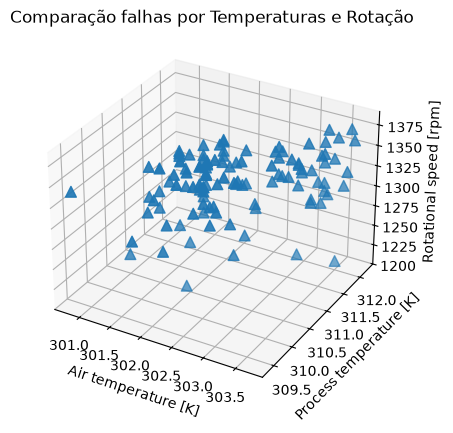

In [95]:
heat_failure_df = failed_clean.copy()
heat_failure_df = heat_failure_df.loc[heat_failure_df[TARGET] == "Heat Dissipation Failure"]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xs = heat_failure_df[heat_cols[0]]
ys = heat_failure_df[heat_cols[1]]
zs = heat_failure_df[heat_cols[2]]
    
ax.scatter(xs,ys,zs, marker='^', s=60)
ax.set_xlabel(heat_cols[0])
ax.set_ylabel(heat_cols[1])
ax.set_zlabel(heat_cols[2])
ax.set_title("Comparação falhas por Temperaturas e Rotação")
plt.show()

Não está muit simples de ver, mas aparentemente maior rotação e maior temperatura no processo tem ligação.

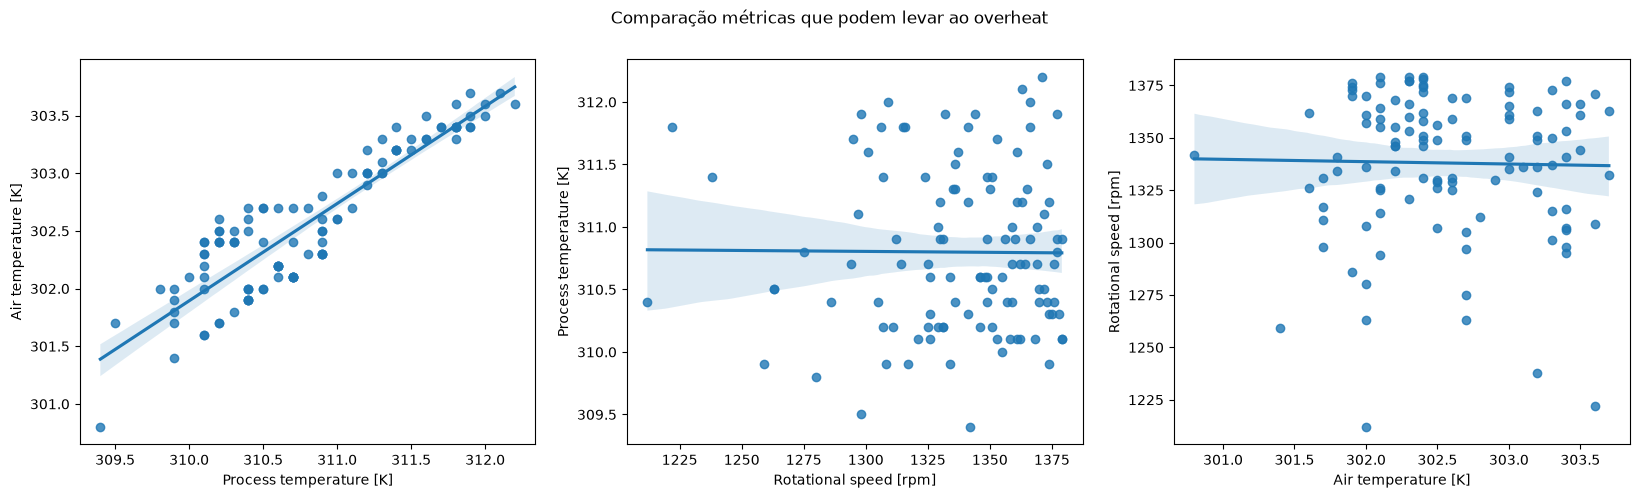

In [113]:
fig,ax = plt.subplots(1,3, figsize=(20,5))
sns.regplot(data=heat_failure_df, x=heat_cols[1], y=heat_cols[0], ax=ax[0])
sns.regplot(data=heat_failure_df, x=heat_cols[2], y=heat_cols[1], ax=ax[1])
sns.regplot(data=heat_failure_df, x=heat_cols[0], y=heat_cols[2], ax=ax[2])
fig.suptitle("Comparação métricas que podem levar ao overheat")
plt.show()

É visto que o quanto maior a temperatura do ambiente maior a do processo.

Duas coisas me vêm a cabeça:
- como fica o rotação pelo tempo
- qual a distribuição de temperatura do processo e falha por superaquecimento

## Falha por superaquecimento distribuição

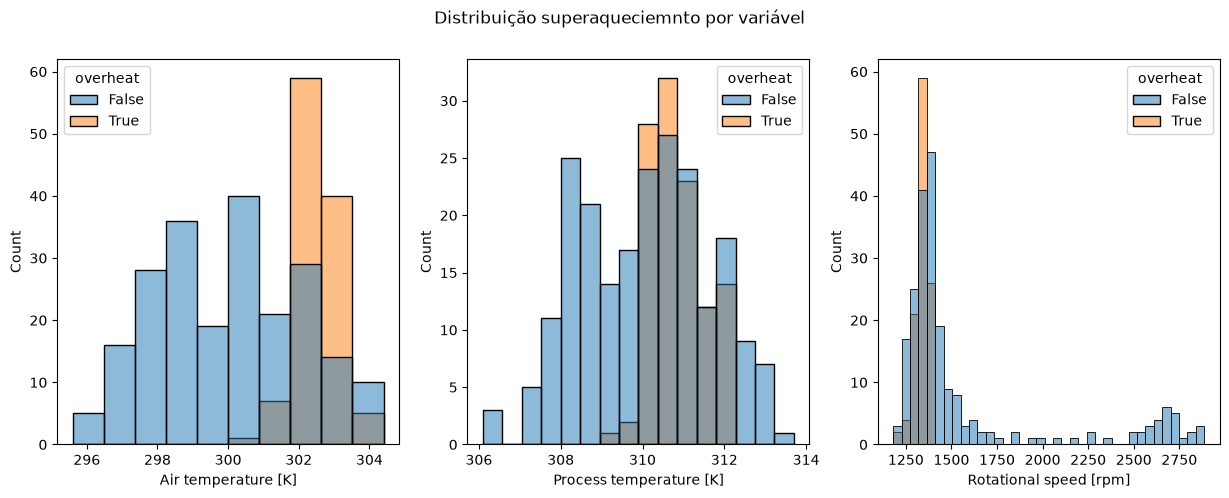

In [124]:
had_overheat_df = failed_clean.copy()
had_overheat_df["overheat"] = False
had_overheat_df.loc[had_overheat_df[TARGET] == "Heat Dissipation Failure","overheat"] = True

fig,ax = plt.subplots(1,3, figsize=(15,5))

sns.histplot(data=had_overheat_df, x=heat_cols[0], hue="overheat",ax=ax[0])
sns.histplot(data=had_overheat_df, x=heat_cols[1], hue="overheat",ax=ax[1])
sns.histplot(data=had_overheat_df, x=heat_cols[2], hue="overheat",ax=ax[2])
fig.suptitle("Distribuição superaqueciemnto por variável")
plt.show()

Neste caso, é possível ver que usando a temperatura ambiente temos um corte melhor. Além disso, é possível ver que no geral os problemas parecem não estar relacionados com a rotação, já que rotações baixas que possuem maior superaquecimento. Talvez rotações menores seram máquinas do tipo L

Poderiamos também:
- Verificar falha por tipo de qualidade
- Verificar quais máquinas tem rotação menor

## Relação Minutos x Rotação x Temperaturas

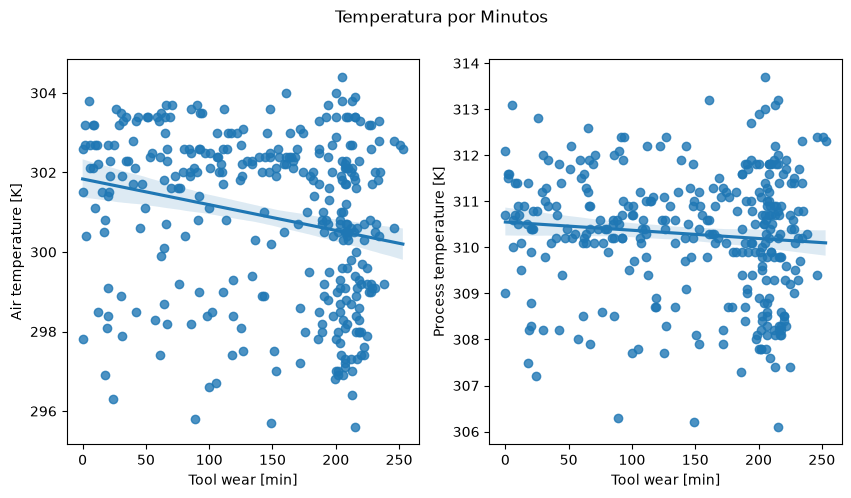

In [135]:
TIME_COL = "Tool wear [min]"

fig,ax = plt.subplots(1,2, figsize=(10,5))
sns.regplot(data=had_overheat_df, x=TIME_COL, y=heat_cols[0], ax=ax[0])
sns.regplot(data=had_overheat_df, x=TIME_COL, y=heat_cols[1], ax=ax[1])
fig.suptitle("Temperatura por Minutos")
plt.show()

Aparentemente não há ligação entre tempo e temperatura

## Falha de Temperatura por tipo

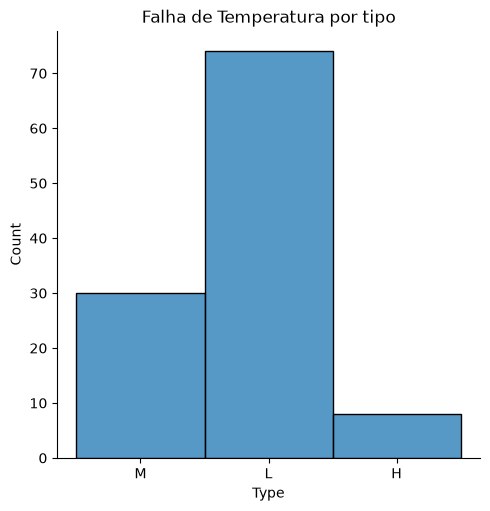

In [138]:
sns.displot(data=heat_failure_df, x="Type")
plt.title("Falha de Temperatura por tipo")
plt.show()

Como esperado, no geral maquinas L e M são mais propensas

## Rotação por tipo de máquina

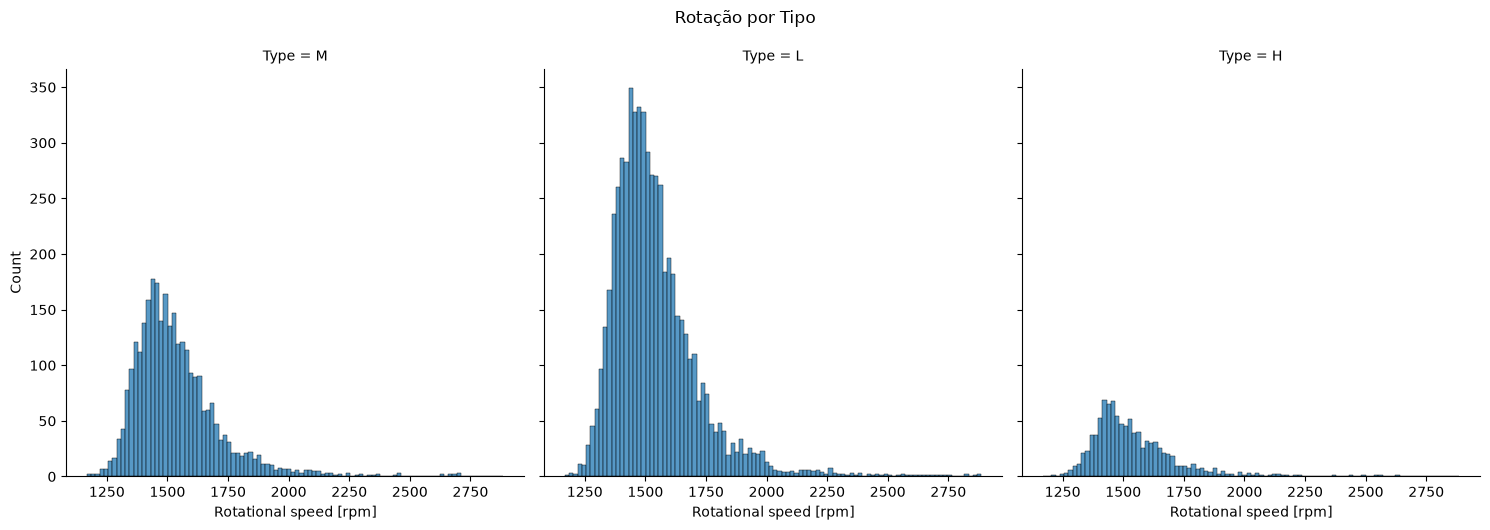

In [144]:
sns.displot(data=df, x='Rotational speed [rpm]', col="Type")
plt.suptitle("Rotação por Tipo",y=1.05)
plt.show()

De certa forma as falhas aparecem mais por volta dos 1250RPM pois é a rotação predominante

Até agora sabemos que:

- A maioria são máquinas L
- para Heat Dissipation usar a temperatura ambiente é o melhor
- para overstrain o melhor é o Nm x Min

## Análise para `Tool Wear Failure`

In [147]:
wear_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', TARGET]
has_wear_df = failed_clean.loc[failed_clean[TARGET] == "Tool Wear Failure"]